<a href="https://colab.research.google.com/github/Jkovv/SARIMA_SPY/blob/main/SARIMA_SPY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance

In [ ]:
pip install pmdarima

In [ ]:
pip install pandas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import shapiro, kstest, normaltest
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
df = yf.download('SPY')

[*********************100%%**********************]  1 of 1 completed


In [ ]:
df.index = pd.to_datetime(df.index)

In [ ]:
split_index = 0.8

original_data = df['Adj Close']
original_len = int(len(original_data) * split_index)
train_data_original = original_data[:original_len]
test_data_original = original_data[original_len:]

x = np.log(original_data)
train_size = int(len(x) * split_index)
train_data = x[:train_size]
test_data = x[train_size:]

y = x.diff().dropna()
train_size_y = int(len(y) * split_index)
train_data_y = y[:train_size_y]
test_data_y = y[train_size_y:]

train_dates_y = train_data_y.index
test_dates_y = test_data_y.index

In [ ]:
train_data.index = pd.to_datetime(train_data.index)
train_data = train_data.asfreq('B')  # Ustawiam częstotliwość na dni robocze (B)

In [ ]:
shapiro_test_original = shapiro(original_data)
print(shapiro_test_original)

ShapiroResult(statistic=0.8113996982574463, pvalue=0.0)


/usr/local/lib/python3.10/dist-packages/scipy/stats/_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


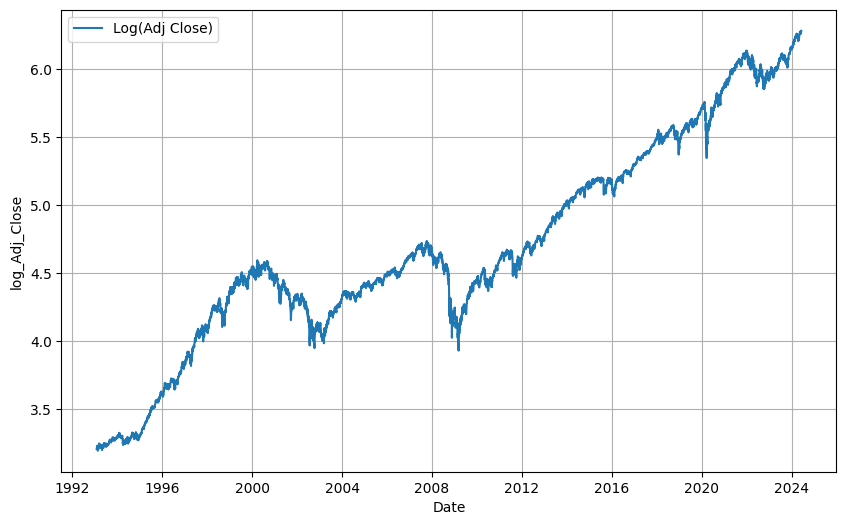

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(x, label='Log(Adj Close)')
plt.xlabel('Date')
plt.ylabel('log_Adj_Close')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller
adftest = adfuller(x, autolag='BIC', regression='ct')
print("ADF Results - x")
print("ADF-Statistic:", adftest[0])
print("P-Value:", adftest[1]) # występuje niestacjonarność

ADF Results - x
ADF-Statistic: -1.8812237745305853
P-Value: 0.66434222065854


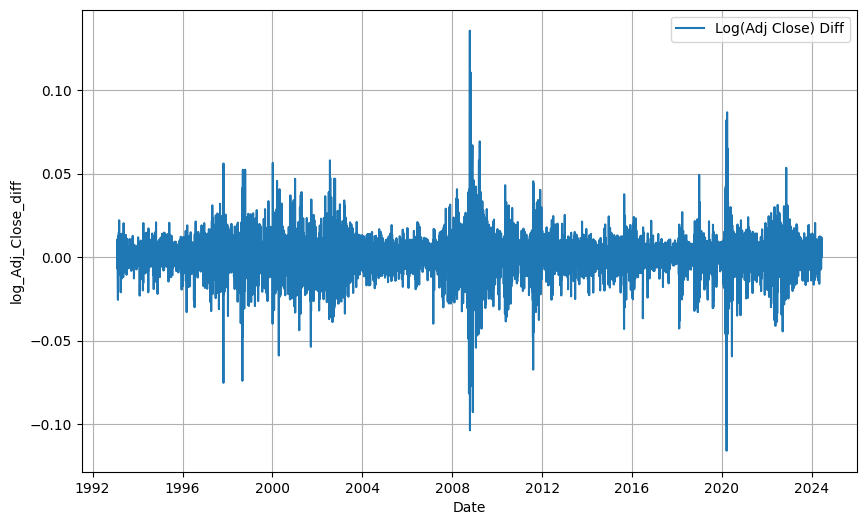

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(y, label='Log(Adj Close) Diff')
plt.xlabel('Date')
plt.ylabel('log_Adj_Close_diff')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller
adftest = adfuller(y, autolag='BIC', regression='ct')
print("ADF Results - y")
print("ADF-Statistic:", adftest[0])
print("P-Value:", adftest[1]) # występuje stacjonarność

ADF Results - y
ADF-Statistic: -96.25301095935771
P-Value: 0.0


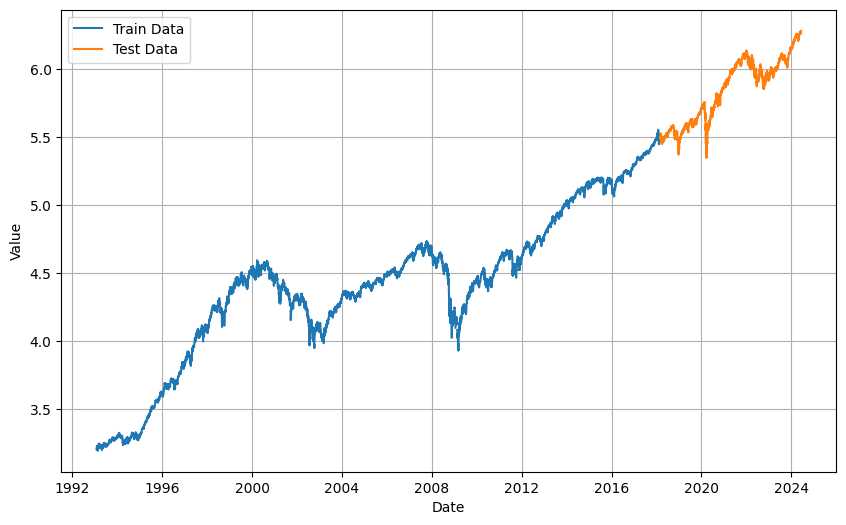

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_data.index, train_data, label='Train Data')
plt.plot(test_data.index, test_data, label='Test Data')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

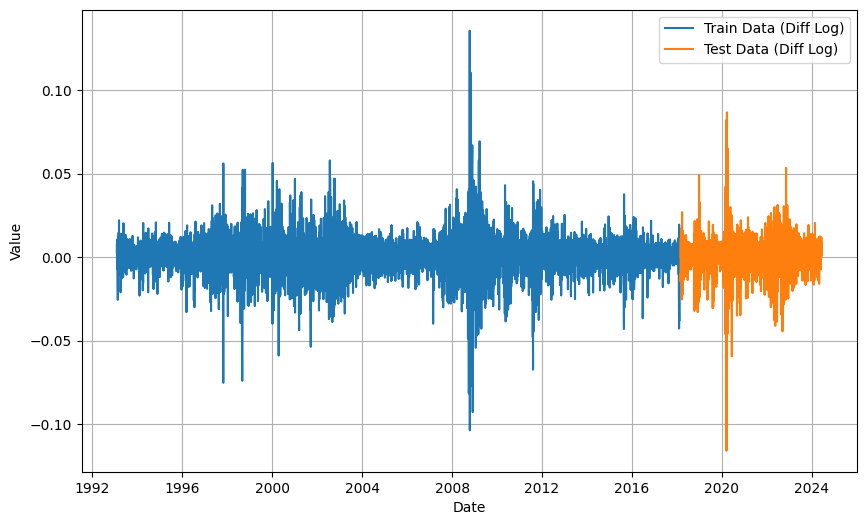

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_dates_y, train_data_y, label='Train Data (Diff Log)')
plt.plot(test_dates_y, test_data_y, label='Test Data (Diff Log)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
adftest = adfuller(train_data.dropna(), autolag='BIC', regression='ct')
print("ADF Test Results (train)")
print("ADF-Statistic:", adftest[0])
print("P-Value:", adftest[1]) # występuje niestacjonarność

print("----------------------------------")

adftest = adfuller(train_data_y, autolag='BIC', regression='ct')
print("ADF Test Results (train_y)")
print("ADF-Statistic:", adftest[0])
print("P-Value:", adftest[1]) # występuje stacjonarność

ADF Test Results (train)
ADF-Statistic: -1.8591570899795586
P-Value: 0.6755595938862726
----------------------------------
ADF Test Results (train_y)
ADF-Statistic: -61.36558153327252
P-Value: 0.0


<Figure size 640x480 with 0 Axes>

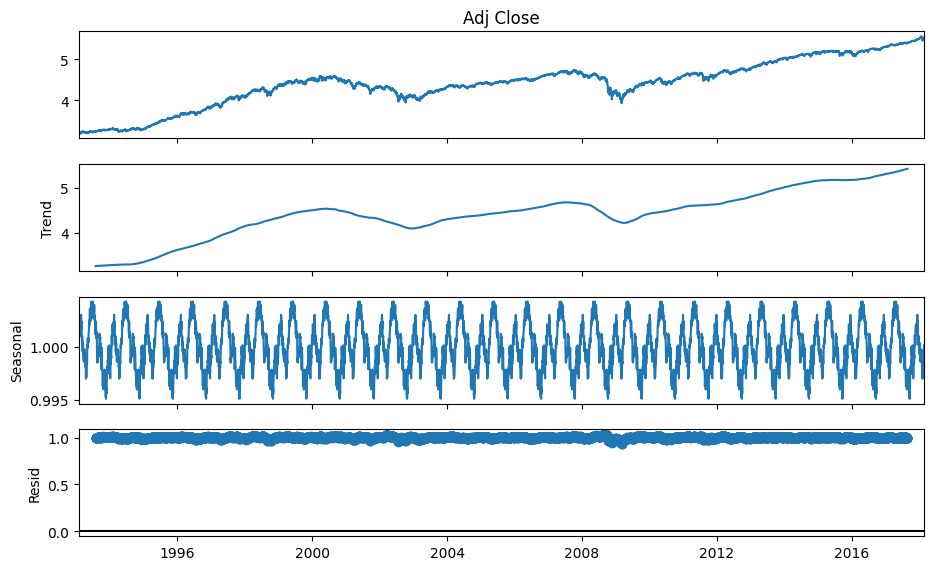

In [ ]:
train_data = train_data.dropna()
result = seasonal_decompose(train_data, model='multiplicative', period=250)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(10, 6)

plt.show()


In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test_y = acorr_ljungbox(train_data_y, lags=range(1, 11), return_df=True)

print("Ljung-Box Test for train_y:")
print(lb_test_y)

Ljung-Box Test for train_y:
      lb_stat     lb_pvalue
1   23.267444  1.409660e-06
2   42.474932  5.979786e-10
3   42.505529  3.133887e-09
4   43.229147  9.274668e-09
5   53.955918  2.140005e-10
6   53.957040  7.525781e-10
7   56.433918  7.744714e-10
8   57.351820  1.537381e-09
9   58.540641  2.559262e-09
10  59.902341  3.781824e-09


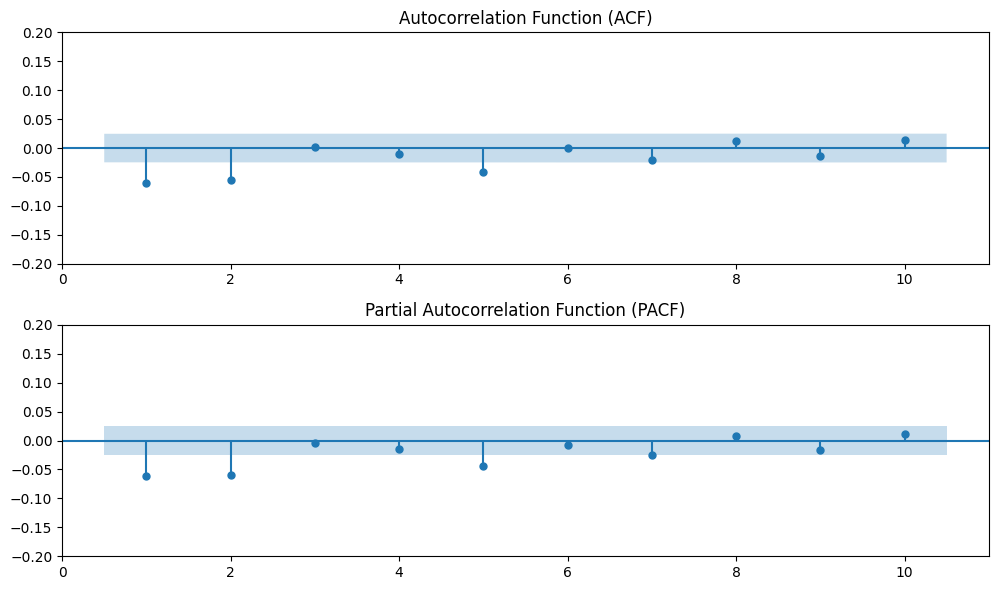

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=False, sharey=False)
plot_acf(train_data_y, lags=10, ax=ax1, zero=False, alpha=0.05)
plot_pacf(train_data_y, lags=10, ax=ax2, zero=False, alpha=0.05)

ax1.set_ylim(-0.2, 0.2)
ax2.set_ylim(-0.2, 0.2)

ax1.set_title('Autocorrelation Function (ACF)')
ax2.set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()


In [ ]:
stepwise_fit = auto_arima(train_data.dropna(), d=1, trace=True, information_criterion='bic') # procedurą Boxa-Jenkinsa po kryterium bic
stepwise_fit.summary()

Performing stepwise search to minimize bic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : BIC=-38393.637, Time=18.34 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : BIC=-38380.661, Time=3.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : BIC=-38395.212, Time=1.92 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : BIC=-38398.132, Time=2.72 sec
 ARIMA(0,1,0)(0,0,0)[0]             : BIC=-38383.150, Time=0.94 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : BIC=-38408.213, Time=3.21 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : BIC=-38400.001, Time=8.63 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : BIC=-38401.246, Time=3.67 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : BIC=-38409.613, Time=7.59 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : BIC=-38400.924, Time=6.88 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : BIC=-38392.493, Time=11.07 sec
 ARIMA(0,1,2)(0,0,0)[0]             : BIC=-38410.200, Time=1.80 sec
 ARIMA(0,1,1)(0,0,0)[0]             : BIC=-38399.655, Time=0.46 sec
 ARIMA(1,1,2)(0,0,0)[0]             : BIC=-38401.635, Time=2.46 sec
 AR

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 6316
Model:               SARIMAX(0, 1, 2)   Log Likelihood               19218.226
Date:                Fri, 07 Jun 2024   AIC                         -38430.452
Time:                        12:28:36   BIC                         -38410.200
Sample:                             0   HQIC                        -38423.437
                               - 6316                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0640      0.007     -8.992      0.000      -0.078      -0.050
ma.L2         -0.0552      0.006     -9.778      0.000      -0.066      -0.044
sigma2         0.0001   1.05e-06    126.639      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             24650.22
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.74   Skew:                            -0.29
Prob(H) (two-sided):                  0.00   Kurtosis:                        12.66
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
p=0
d=1
q=2

In [ ]:
import statsmodels.api as sm
import warnings
model=sm.tsa.statespace.SARIMAX(train_data,
                                order=(p, d, q),
                                seasonal_order=(p, d, q, 4)) #występuje sezonowość kwartalna, co widać po wykresie seasonality na początku
model=model.fit()
print(model.summary())

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                     
Dep. Variable:                         Adj Close   No. Observations:                 6316
Model:             SARIMAX(0, 1, 2)x(0, 1, 2, 4)   Log Likelihood               19196.265
Date:                           Fri, 07 Jun 2024   AIC                         -38382.529
Time:                                   12:28:48   BIC                         -38348.779
Sample:                                        0   HQIC                        -38370.838
                                          - 6316                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0729      0.007     -9.915      0.000      -0.087      -0.059
ma.L2         -0.0738      0.006    -13.077

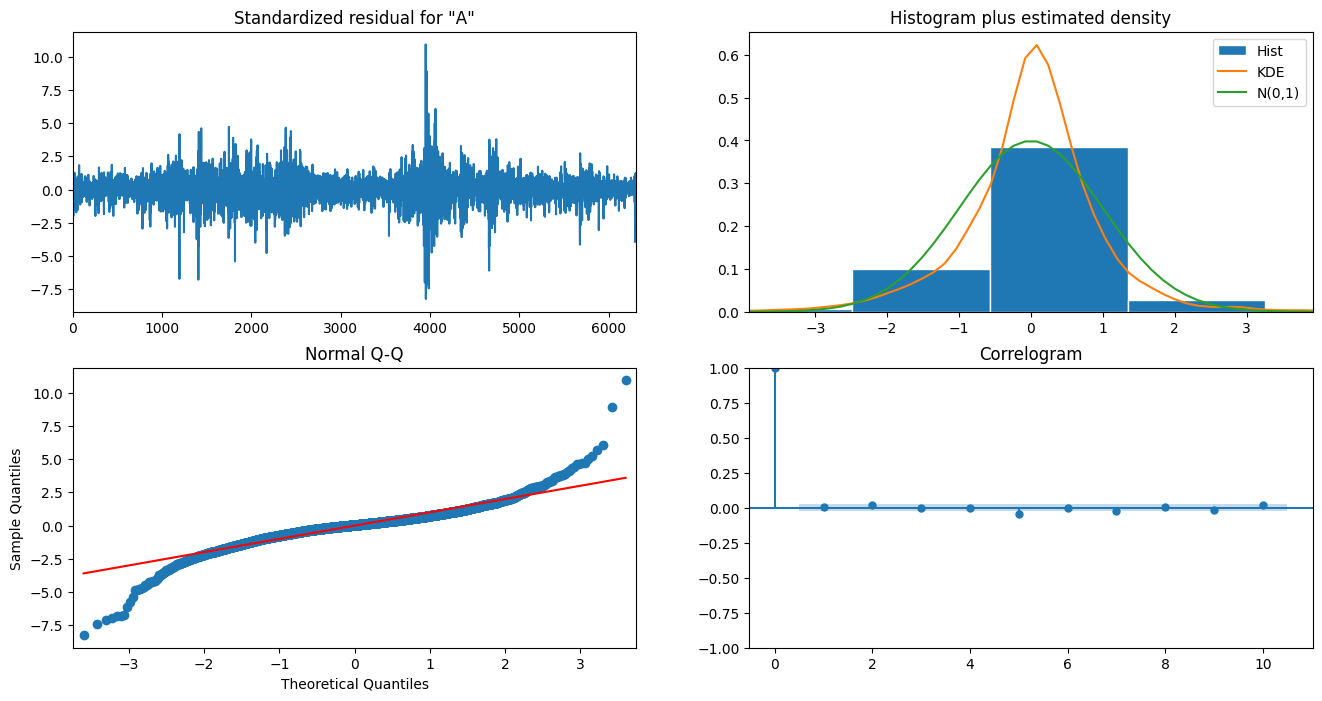

In [ ]:
model.plot_diagnostics(figsize=(16, 8))
plt.savefig('modeldiagnostics')
plt.show()

In [ ]:
predictions = model.predict(len(train_data), len(train_data)+len(test_data)-1)
print(predictions)

6316    5.511785
6317    5.513234
6318    5.513014
6319    5.513570
6320    5.514393
          ...   
7890    6.289949
7891    6.290328
7892    6.291150
7893    6.291989
7894    6.291926
Name: predicted_mean, Length: 1579, dtype: float64


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


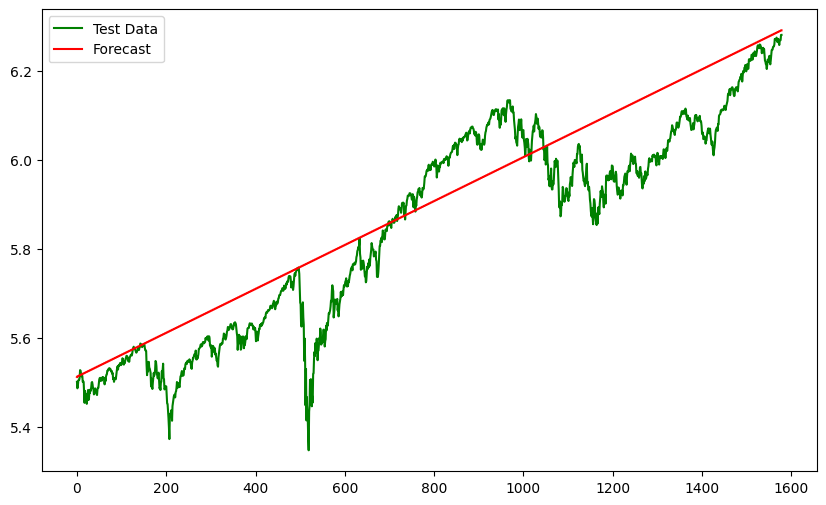

In [ ]:
plt.figure(figsize=(10, 6))
index = range(len(test_data))
plt.plot(index, test_data, color="green", label='Test Data')
plt.plot(index, predictions, color='red', label='Forecast')
plt.legend()
plt.show()

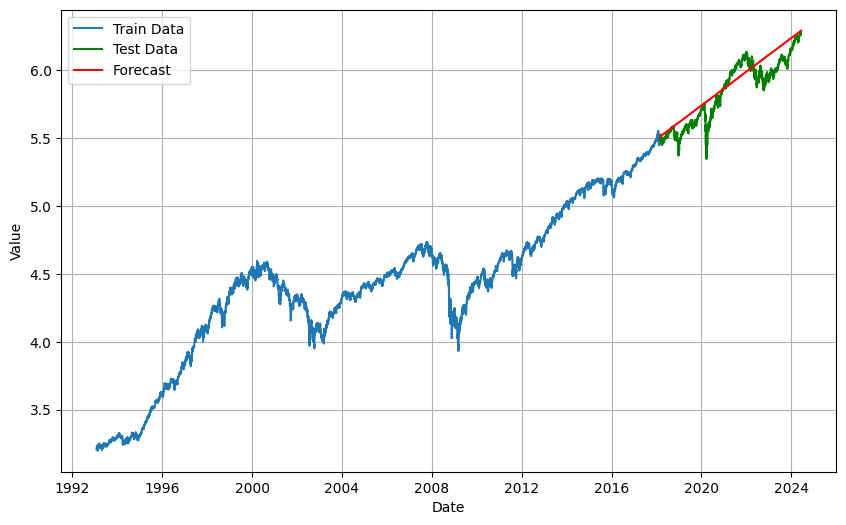

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_data.index, train_data, label='Train Data')
plt.plot(test_data.index, test_data, color="green", label='Test Data')
plt.plot(test_data.index, predictions, color="red", label='Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(test_data, predictions)
print("MSE:", mse)

MSE: 0.011154269152438528
